# Stretch real data

## Load data

In [ ]:
import gdown
import os

# ID файла в Google Drive
file_id_1 = "1AcNtaITqcvzpXGMOO3PPUPQT17mrHEk5"
#https://drive.google.com/file/d/1AcNtaITqcvzpXGMOO3PPUPQT17mrHEk5/view?usp=drive_link
file_id_2 = "13V4CT-xrwJIUwjew5uWCaKrFHvDkOHub"
#https://drive.google.com/file/d/13V4CT-xrwJIUwjew5uWCaKrFHvDkOHub/view?usp=drive_link
file_id_3 = "1XyrotTKSTzHLSHF0RybWTuI418tasL1B"
#https://drive.google.com/file/d/1XyrotTKSTzHLSHF0RybWTuI418tasL1B/view?usp=drive_link
file_id_4 = "1Hs5na6XINlNGr_Dafl3GYTJs5tcRD97z"
#https://drive.google.com/file/d/1Hs5na6XINlNGr_Dafl3GYTJs5tcRD97z/view?usp=drive_link

# Папка для сохранения
folder = "data/data_las"
os.makedirs(folder, exist_ok=True)

# Путь для сохранения файла
file_1 = os.path.join(folder, "OCCC_points.las")
file_2 = os.path.join(folder, "RA_points.las")
file_3 = os.path.join(folder, "USC_points.las")
file_4 = os.path.join(folder, "WMSC_points.las")

# Загрузка файла
gdown.download(f"https://drive.google.com/uc?id={file_id_1}", file_1, quiet=False)
gdown.download(f"https://drive.google.com/uc?id={file_id_2}", file_2, quiet=False)
gdown.download(f"https://drive.google.com/uc?id={file_id_3}", file_3, quiet=False)
gdown.download(f"https://drive.google.com/uc?id={file_id_4}", file_4, quiet=False)

print(f"File successfully uploaded to: {file_1}")
print(f"File successfully uploaded to: {file_2}")
print(f"File successfully uploaded to: {file_3}")
print(f"File successfully uploaded to: {file_4}")

Downloading...
From (original): https://drive.google.com/uc?id=1AcNtaITqcvzpXGMOO3PPUPQT17mrHEk5
From (redirected): https://drive.google.com/uc?id=1AcNtaITqcvzpXGMOO3PPUPQT17mrHEk5&confirm=t&uuid=4d802cb0-eb95-4c30-8f99-632e8d13d8e5
To: /home/alexey/MUSAC/codes/lidar-visual-interface/training/notebook/data/data_las/OCCC_points.las
100%|██████████| 170M/170M [00:01<00:00, 89.0MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=13V4CT-xrwJIUwjew5uWCaKrFHvDkOHub
From (redirected): https://drive.google.com/uc?id=13V4CT-xrwJIUwjew5uWCaKrFHvDkOHub&confirm=t&uuid=7ce17532-b26c-4499-9c66-0708ee79d765
To: /home/alexey/MUSAC/codes/lidar-visual-interface/training/notebook/data/data_las/RA_points.las
100%|██████████| 170M/170M [00:02<00:00, 84.0MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1XyrotTKSTzHLSHF0RybWTuI418tasL1B
From (redirected): https://drive.google.com/uc?id=1XyrotTKSTzHLSHF0RybWTuI418tasL1B&confirm=t&uuid=5bf05e2a-a301-459a-8d05-696b6d4238dd

Файл успешно загружен в: data/data_las/OCCC_points.las
Файл успешно загружен в: data/data_las/RA_points.las
Файл успешно загружен в: data/data_las/USC_points.las
Файл успешно загружен в: data/data_las/WMSC_points.las


## import modules for stretching las

In [4]:
import sys

sys.path.append('../utils')  
from stretch_las import (
    scale_to_nearest_grid,
    shift_to_center,
    cartesian_to_polar,
    compute_max_r_per_phi_bin,
    circular_linear_interp,
    compute_r
    )

['RA_points.las', 'USC_points.las', 'OCCC_points.las', 'WMSC_points.las']
file is processing:  RA_points.las
5000000


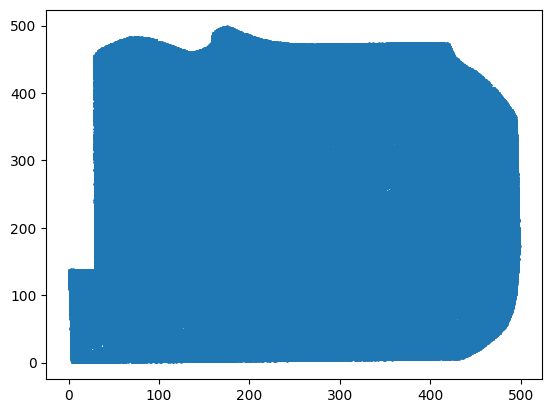

Half-width a = 249.3400
Half-height b = 249.3300


/home/alexey/MUSAC/codes/lidar-visual-interface/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


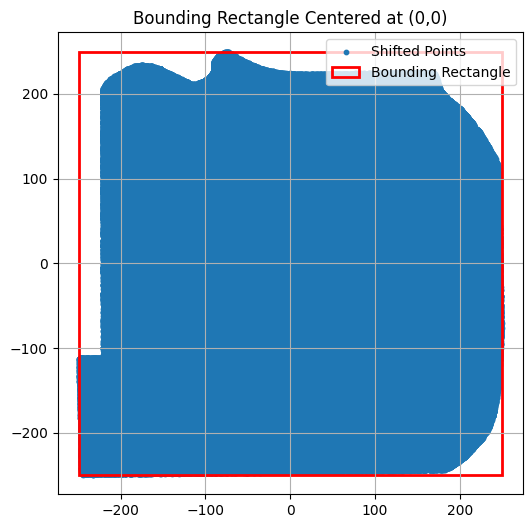

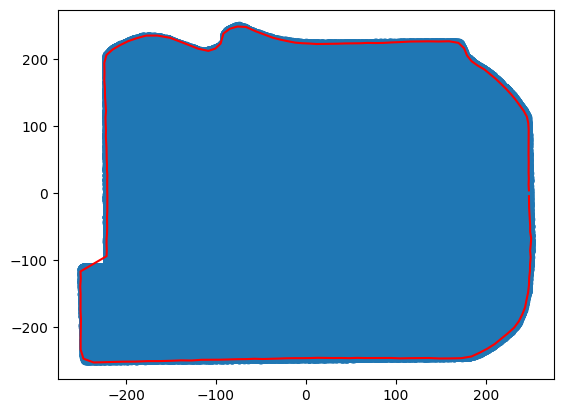

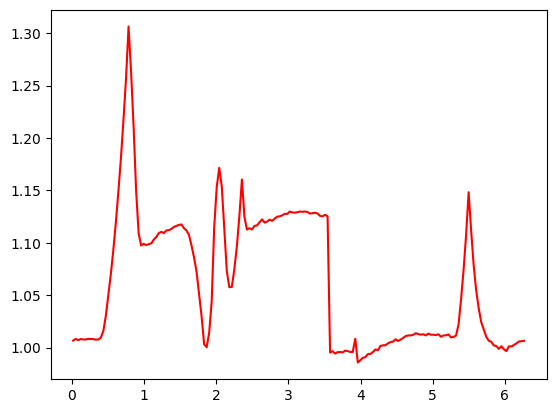

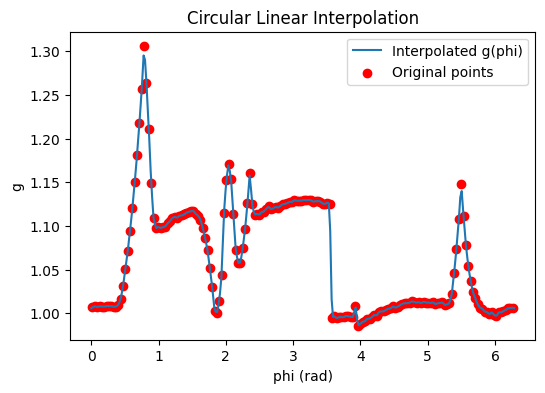

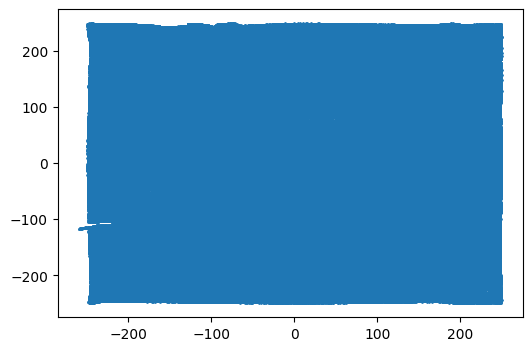

file is processing:  USC_points.las
5000000


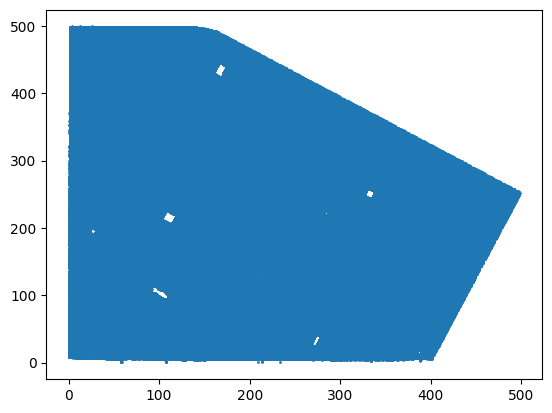

Half-width a = 249.0550
Half-height b = 249.3450


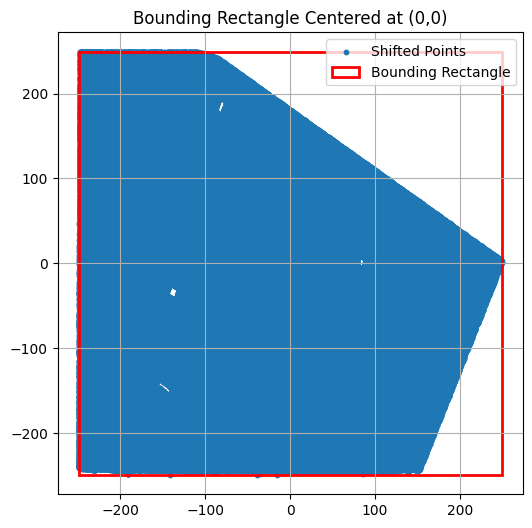

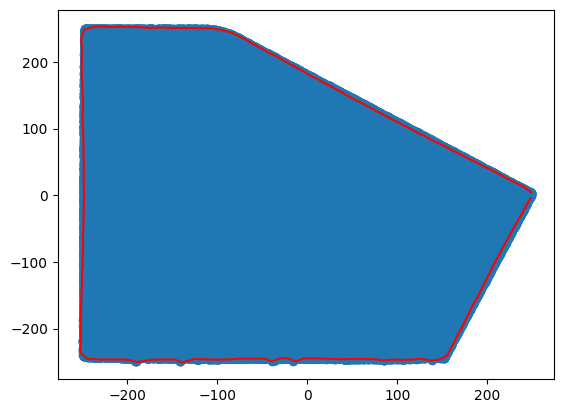

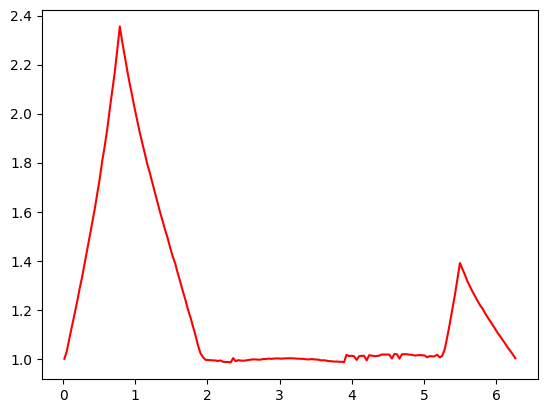

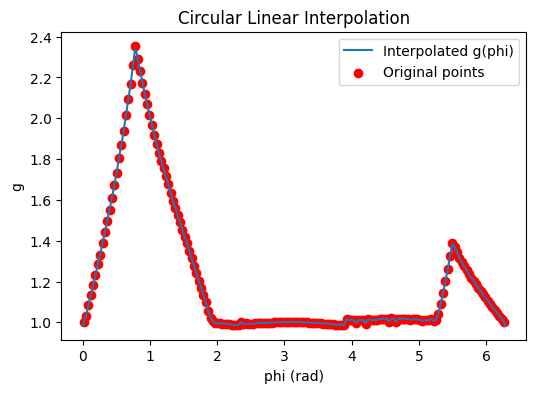

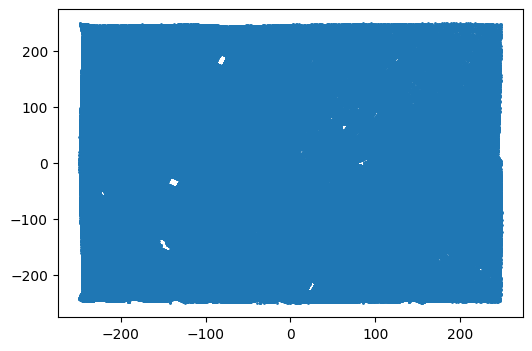

file is processing:  OCCC_points.las
5000000


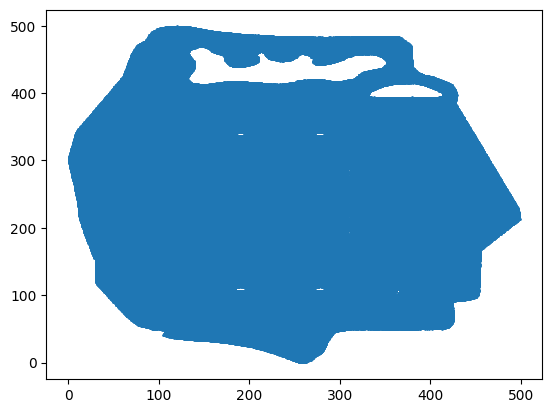

Half-width a = 249.2250
Half-height b = 249.4400


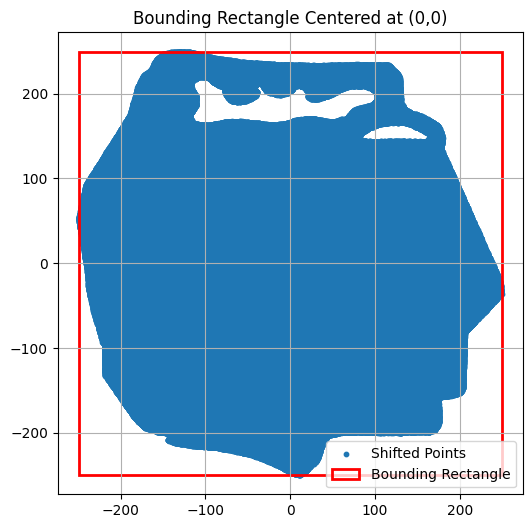

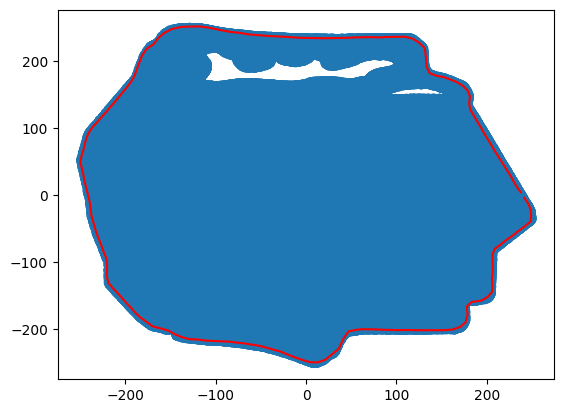

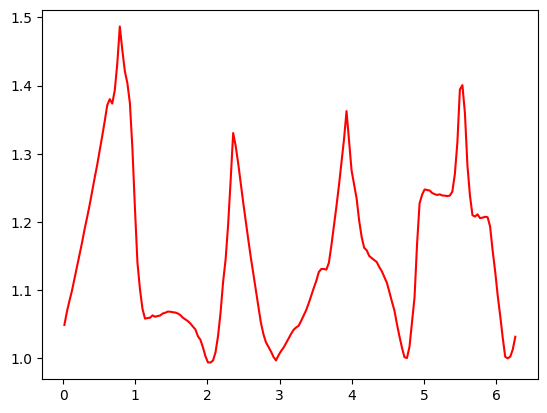

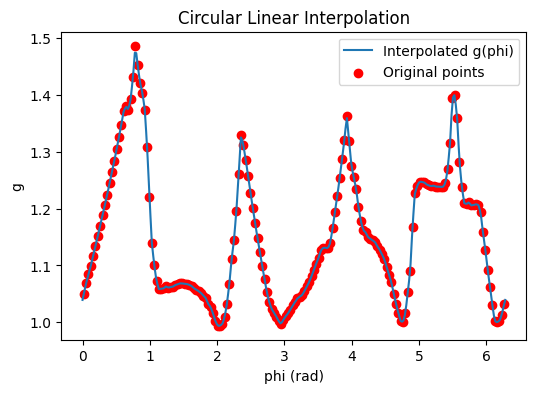

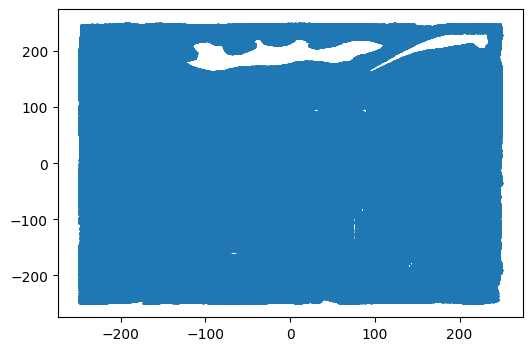

file is processing:  WMSC_points.las
5000000


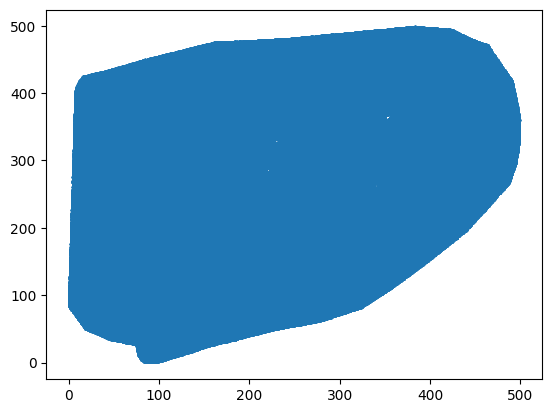

Half-width a = 249.4200
Half-height b = 249.2900


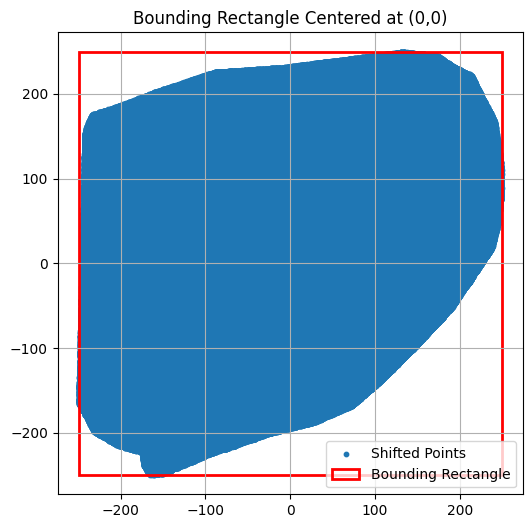

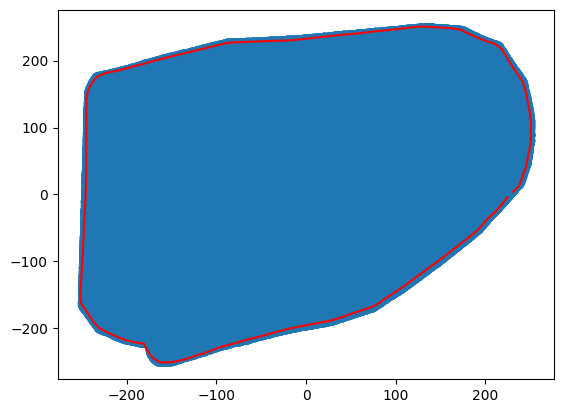

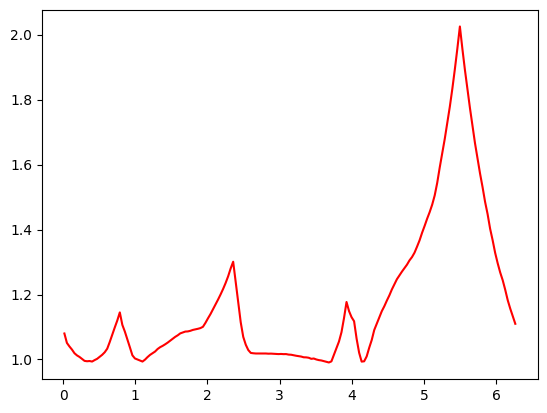

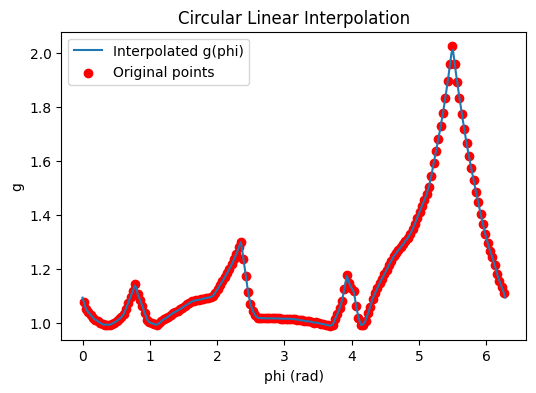

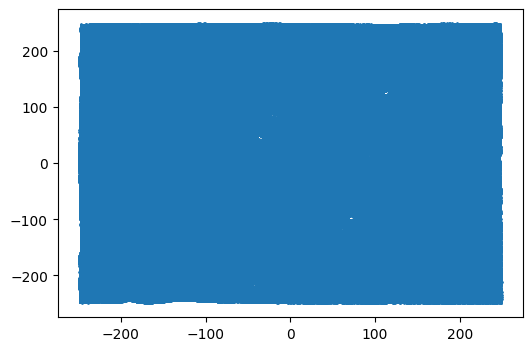

In [5]:
import laspy
import os
import numpy as np
import matplotlib.pyplot as plt

input_directory = "data/data_las"
output_directory = "data/data_las_stretched"

tile_size = 250

os.makedirs(output_directory, exist_ok=True)
# Get list of .las files
filenames = [f for f in os.listdir(input_directory) if f.endswith('.las')]
print(filenames)
for filename in filenames:
    print("file is processing: ", filename)
    file_path = os.path.join(input_directory, filename)
    # Load .las file using laspy
    las = laspy.read(file_path)
    # Extract coordinates
    x_org = las.x
    y_org = las.y
    z_org = las.z

    cls_org = las.classification

    # Extract color (if available in the file)
    try:
        r_org = las.red
        g_org = las.green
        b_org = las.blue
    except AttributeError:
        r_org = g_org = b_org = None
        print("No color data available in the file.")

    N = len(x_org)
    print(N)
    K = 1000_000
    idx = np.random.choice(N, size=K, replace=False)  # randomly select 1 million indices without replacement

    plt.scatter(x_org[idx], y_org[idx], s=1)
    plt.show()
    x_shifted, y_shifted, a, b = shift_to_center(x_org[idx], y_org[idx], is_plot=True)
    r, phi = cartesian_to_polar(x_shifted, y_shifted)
    
    r_i = r
    phi_i = phi

    N = 90
    # Set angular grid with step dphi
    dphi = np.pi / N  # 10 degrees
    phi_b_i = np.arange(0, 2 * np.pi + dphi, dphi)
    phi_c_i = (phi_b_i[:-1] + phi_b_i[1:]) / 2

    R_j = compute_max_r_per_phi_bin(r_i, phi_i, phi_b_i)

    plt.scatter(r * np.cos(phi), r * np.sin(phi))
    plt.plot(R_j * np.cos(phi_c_i), R_j * np.sin(phi_c_i), c='r')
    plt.show()

    r_rec = compute_r(phi_c_i, a, b)

    g = r_rec / R_j

    plt.plot(phi_c_i, g, c='r')

    interp_g = circular_linear_interp(phi_c_i, g)

    # Evaluate on new angles
    phi_test = np.linspace(0, 2 * np.pi, 300)
    g_test = interp_g(phi_test)

    # Visualization
    plt.figure(figsize=(6, 4))
    plt.plot(phi_test, g_test, label='Interpolated g(phi)')
    plt.scatter(phi_c_i, g, color='red', label='Original points')
    plt.xlabel('phi (rad)')
    plt.ylabel('g')
    plt.legend()
    plt.title('Circular Linear Interpolation')
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.scatter(interp_g(phi) * r * np.cos(phi), interp_g(phi) * r * np.sin(phi), s=1)
    plt.show()

    # Compute new coordinates
    x_new = interp_g(phi) * r * np.cos(phi)
    y_new = interp_g(phi) * r * np.sin(phi)
    z_new = z_org[idx]

    r_new = r_org[idx]
    g_new = g_org[idx]
    b_new = b_org[idx]
    cls_new = cls_org[idx]

    # Initialize LAS file with RGB support
    header = laspy.LasHeader(point_format=3, version="1.2")  # Point format 3 includes RGB
    las = laspy.LasData(header)

    # Set coordinates
    x_new -= np.min(x_new)
    y_new -= np.min(y_new)

    x_new, y_new = scale_to_nearest_grid(x_new, y_new, grid_size=tile_size)
    
    las.x = x_new
    las.y = y_new
    las.z = z_new

    # Set colors
    las.red = r_new
    las.green = g_new
    las.blue = b_new

    # Set classes
    las.classification = cls_new

    # Save file
    file_path = os.path.join(output_directory, filename)
    las.write(file_path)